# Proyek Klasifikasi Gambar: Animals-10
- **Nama:** Aliyah Nadhratunnaim
- **Email:** CACC001D6X0807@student.devacademy.id
- **ID Dicoding:** CACC001D6X0807

Klasifikasi gambar hewan berguna untuk berbagai aplikasi seperti identifikasi satwa liar dan media pembelajaran. Dataset Animals-10 yang digunakan dalam proyek ini dapat diakses melalui tautan https://www.kaggle.com/datasets/alessiocorrado99/animals10 . MobileNetV2 dipilih karena arsitekturnya yang ringan dan efisien, cocok untuk perangkat dengan sumber daya terbatas.

## Import Semua Packages/Library yang Digunakan

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
import shutil
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from PIL import Image
import matplotlib.pyplot as plt
import random
from PIL import Image
from tensorflow.keras.preprocessing import image
from sklearn.metrics import classification_report, confusion_matrix

## Data Preparation

### Data Loading

In [ ]:
data_dir = '/kaggle/input/datasets/alessiocorrado99/animals10/raw-img'

print("MENGECEK RESOLUSI GAMBAR ASLI")

all_sizes = []
size_count = {}
class_sizes = {}

# Loop semua folder kelas
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path) and not class_name.startswith('.'):
        print(f"\n📁 Kelas: {class_name}")

        sizes_this_class = []

        # Ambil 10 gambar pertama aja (biar cepet)
        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        for img_name in images[:10]:  # Cek 10 gambar per kelas
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    size = img.size  # (width, height)
                    all_sizes.append(size)
                    sizes_this_class.append(size)

                    # Hitung frekuensi ukuran
                    if size in size_count:
                        size_count[size] += 1
                    else:
                        size_count[size] = 1
            except Exception as e:
                print(f"  Error: {img_name} - {e}")

        # Tampilkan resolusi di kelas ini
        unique_sizes = set(sizes_this_class)
        for s in unique_sizes:
            print(f"  → Resolusi: {s[0]} x {s[1]}")
            class_sizes[class_name] = unique_sizes

        print(f"  Total gambar di kelas: {len(images)}")

print("RINGKASAN RESOLUSI")

# Tampilkan semua resolusi yang ditemukan
print("\nResolusi yang ditemukan di dataset:")
for size, count in sorted(size_count.items(), key=lambda x: x[1], reverse=True):
    print(f"  {size[0]} x {size[1]} : {count} gambar")

MENGECEK RESOLUSI GAMBAR ASLI

📁 Kelas: cavallo
  → Resolusi: 225 x 300
  → Resolusi: 300 x 225
  → Resolusi: 200 x 300
  → Resolusi: 300 x 199
  → Resolusi: 300 x 169
  → Resolusi: 300 x 252
  → Resolusi: 300 x 213
  → Resolusi: 300 x 197
  → Resolusi: 300 x 300
  Total gambar di kelas: 2623

📁 Kelas: pecora
  → Resolusi: 640 x 442
  → Resolusi: 640 x 426
  → Resolusi: 300 x 225
  → Resolusi: 300 x 257
  → Resolusi: 300 x 157
  → Resolusi: 640 x 428
  → Resolusi: 300 x 160
  → Resolusi: 300 x 201
  Total gambar di kelas: 1820

📁 Kelas: elefante
  → Resolusi: 640 x 426
  → Resolusi: 300 x 225
  → Resolusi: 300 x 199
  → Resolusi: 300 x 227
  → Resolusi: 300 x 150
  → Resolusi: 640 x 359
  → Resolusi: 640 x 423
  → Resolusi: 300 x 216
  → Resolusi: 300 x 200
  Total gambar di kelas: 1446

📁 Kelas: gatto
  → Resolusi: 300 x 225
  → Resolusi: 300 x 164
  → Resolusi: 300 x 200
  → Resolusi: 300 x 247
  → Resolusi: 300 x 169
  → Resolusi: 300 x 188
  → Resolusi: 269 x 194
  → Resolusi: 300 

**Dataset ini memiliki resolusi gambar yang beragam**, mulai dari ukuran kecil seperti 174×300 hingga ukuran yang lebih besar seperti 640×442, dengan resolusi paling umum adalah 300×225. Variasi resolusi ini menunjukkan bahwa gambar-gambar dalam dataset berasal dari sumber yang berbeda-beda.

📂 Mengumpulkan path gambar...
✅ Total gambar ditemukan: 26179 gambar
📊 Total kelas: 10 kelas


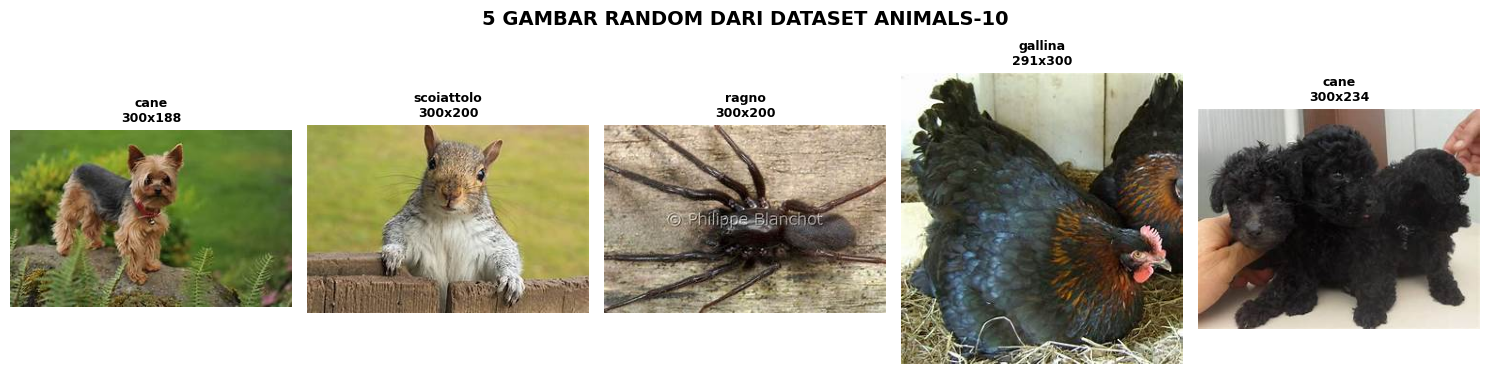

In [ ]:
# Kumpulkan semua path gambar dari semua kelas
all_images_path = []
all_images_class = []

print("📂 Mengumpulkan path gambar...")

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path) and not class_name.startswith('.'):
        # Ambil semua gambar di kelas ini
        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            all_images_path.append(img_path)
            all_images_class.append(class_name)

print(f"✅ Total gambar ditemukan: {len(all_images_path)} gambar")
print(f"📊 Total kelas: {len(set(all_images_class))} kelas")

# Pilih 5 gambar RANDOM
random_indices = random.sample(range(len(all_images_path)), 5)

# Tampilkan 5 gambar random
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for i, idx in enumerate(random_indices):
    img_path = all_images_path[idx]
    class_name = all_images_class[idx]

    # Load dan tampilkan gambar
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f"{class_name}\n{img.size[0]}x{img.size[1]}", fontsize=9, fontweight='bold')
    axes[i].axis('off')

plt.suptitle("5 GAMBAR RANDOM DARI DATASET ANIMALS-10", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Data Preprocessing

#### Split Dataset

Dataset dibagi menjadi tiga bagian, yaitu data training, validation, dan test dengan perbandingan 70:15:15.

In [ ]:
print("MEMBAGI DATASET")

# Buat folder baru untuk data yang sudah dibagi
base_dir = '/kaggle/working/split_data'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Hapus folder lama jika ada
for dir_path in [train_dir, val_dir, test_dir]:
    if os.path.exists(dir_path):
        shutil.rmtree(dir_path)
    os.makedirs(dir_path)

# Bagi data per kelas
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path) and not class_name.startswith('.'):
        # Dapatkan semua gambar di kelas ini
        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        # Acak urutan gambar
        np.random.shuffle(images)

        n_total = len(images)
        n_train = int(0.7 * n_total)
        n_val = int(0.15 * n_total)
        n_test = n_total - n_train - n_val

        # Bagi gambar
        train_images = images[:n_train]
        val_images = images[n_train:n_train + n_val]
        test_images = images[n_train + n_val:]

        # Buat folder kelas di masing-masing direktori
        os.makedirs(os.path.join(train_dir, class_name))
        os.makedirs(os.path.join(val_dir, class_name))
        os.makedirs(os.path.join(test_dir, class_name))

        # Copy gambar ke folder masing-masing
        for img in train_images:
            src = os.path.join(class_path, img)
            dst = os.path.join(train_dir, class_name, img)
            shutil.copy(src, dst)

        for img in val_images:
            src = os.path.join(class_path, img)
            dst = os.path.join(val_dir, class_name, img)
            shutil.copy(src, dst)

        for img in test_images:
            src = os.path.join(class_path, img)
            dst = os.path.join(test_dir, class_name, img)
            shutil.copy(src, dst)

        print(f"\n{class_name}:")
        print(f"  Train: {len(train_images)} gambar")
        print(f"  Val: {len(val_images)} gambar")
        print(f"  Test: {len(test_images)} gambar")

print("\nDataset berhasil dibagi!")

MEMBAGI DATASET

cavallo:
  Train: 1836 gambar
  Val: 393 gambar
  Test: 394 gambar

pecora:
  Train: 1274 gambar
  Val: 273 gambar
  Test: 273 gambar

elefante:
  Train: 1012 gambar
  Val: 216 gambar
  Test: 218 gambar

gatto:
  Train: 1167 gambar
  Val: 250 gambar
  Test: 251 gambar

scoiattolo:
  Train: 1303 gambar
  Val: 279 gambar
  Test: 280 gambar

gallina:
  Train: 2168 gambar
  Val: 464 gambar
  Test: 466 gambar

ragno:
  Train: 3374 gambar
  Val: 723 gambar
  Test: 724 gambar

mucca:
  Train: 1306 gambar
  Val: 279 gambar
  Test: 281 gambar

cane:
  Train: 3404 gambar
  Val: 729 gambar
  Test: 730 gambar

farfalla:
  Train: 1478 gambar
  Val: 316 gambar
  Test: 318 gambar

Dataset berhasil dibagi!


#### Resize Gambar

In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

Gambar-gambar ini di-resize menjadi ukuran 224x224 piksel sesuai dengan konfigurasi IMG_HEIGHT dan IMG_WIDTH, serta akan diproses dalam batch berukuran 32 gambar (BATCH_SIZE) untuk mempermudah proses training model.

#### Augmentasi Data

Selanjutnya, dilakukan persiapan data untuk proses training, validation, dan testing. Data training akan mengalami augmentasi seperti rotasi, pergeseran, zoom, dan flip horizontal untuk memperkaya variasi gambar dan mencegah overfitting, sedangkan data validation dan testing hanya dinormalisasi tanpa augmentasi agar tetap merepresentasikan data asli.

In [ ]:
# Untuk training (dengan augmentasi)
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalisasi
    rotation_range=20,        # Rotasi gambar
    width_shift_range=0.1,    # Geser horizontal
    height_shift_range=0.1,   # Geser vertikal
    shear_range=0.1,          # Miringkan gambar
    zoom_range=0.1,           # Zoom in/out
    horizontal_flip=True,     # Balik horizontal
    fill_mode='nearest'       # Isi area kosong
)

# Untuk validation (tanpa augmentasi)
val_datagen = ImageDataGenerator(rescale=1./255)

# Untuk test (tanpa augmentasi)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\n📊 RINGKASAN DATA:")
print(f"   Training: {train_generator.samples} gambar")
print(f"   Validation: {validation_generator.samples} gambar")
print(f"   Test: {test_generator.samples} gambar")
print(f"   Jumlah kelas: {train_generator.num_classes}")
print(f"   Nama kelas: {list(train_generator.class_indices.keys())}")

Found 18322 images belonging to 10 classes.
Found 3922 images belonging to 10 classes.
Found 3935 images belonging to 10 classes.

📊 RINGKASAN DATA:
   Training: 18322 gambar
   Validation: 3922 gambar
   Test: 3935 gambar
   Jumlah kelas: 10
   Nama kelas: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


Dataset ini memiliki **10 kelas hewan** dengan nama dalam bahasa Italia, yaitu: cane (anjing), cavallo (kuda), elefante (gajah), farfalla (kupu-kupu), gallina (ayam), gatto (kucing), mucca (sapi), pecora (domba), ragno (laba-laba), dan scoiattolo (tupai). Model akan mengklasifikasikan gambar hewan ke dalam salah satu dari 10 kelas tersebut berdasarkan pola yang dipelajari selama proses training.

## Modelling

Model dibangun menggunakan transfer learning MobileNetV2 yang telah dilatih dengan ImageNet. Base model di-freeze, kemudian ditambahkan **Sequential** head yang terdiri dari **Conv2D** dengan 256 filter, BatchNormalization, **MaxPooling2D**, serta **GlobalAveragePooling2D**. Selanjutnya ditambahkan Dense layer dengan dropout sebelum output layer untuk klasifikasi 10 kelas hewan. Model dikompilasi dengan optimizer Adam, loss categorical crossentropy, dan metrik akurasi.

In [ ]:
print("MEMBANGUN MODEL MOBILENETV2 DENGAN SEQUENTIAL HEAD")

NUM_CLASSES = 10

# Load base model MobileNetV2 (pretrained)
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Freeze base model biar ga overfit
base_model.trainable = False

# SEQUENTIAL HEAD dengan Conv2D yang tidak overfit
head = Sequential([
    # Conv2D dengan filter 256 (aman)
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Global Pooling
    GlobalAveragePooling2D(),

    # Dense layers
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

# Gabungkan model
model = Sequential([
    base_model,
    head
])

# Kompilasi
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Tampilkan summary
model.summary()

print(f"\n✅ Model siap!")
print(f"Total parameter: {model.count_params():,}")

MEMBANGUN MODEL MOBILENETV2 DENGAN SEQUENTIAL HEAD


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 10)             │     3,050,378 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,308,362 (20.25 MB)

 Trainable params: 3,049,866 (11.63 MB)

 Non-trainable params: 2,258,496 (8.62 MB)


✅ Model siap!
Total parameter: 5,308,362


### Callback

Selanjutnya, dilakukan **Callback** untuk mengoptimalkan proses training.

In [ ]:
# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1),
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

### Training Model

In [ ]:
# Training
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

# Evaluasi pake model terbaik
print("\nMemuat model terbaik...")
from tensorflow.keras.models import load_model
best_model = load_model('best_model.h5')

# Evaluasi model terbaik
test_loss, test_acc = best_model.evaluate(test_generator, verbose=1)
print(f"\n✅ Test Accuracy (Best Model): {test_acc:.4f} ({test_acc*100:.2f}%)")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1777254635.532916     177 service.cc:152] XLA service 0x78bd78003f60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777254635.532956     177 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777254635.532959     177 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777254636.917517     177 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-27 01:50:47.614489: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-27 01:50:47.752875: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1777254651.868449     177 device_co

 82/573 ━━━━━━━━━━━━━━━━━━━━ 2:53 354ms/step - accuracy: 0.6536 - loss: 1.1268

2026-04-27 01:51:30.609777: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-27 01:51:30.748443: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


...

573/573 ━━━━━━━━━━━━━━━━━━━━ 205s 357ms/step - accuracy: 0.9539 - loss: 0.1570 - val_accuracy: 0.9531 - val_loss: 0.1807 - learning_rate: 5.0000e-04
Epoch 6/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.9562 - loss: 0.1435
Epoch 6: val_accuracy did not improve from 0.95309
573/573 ━━━━━━━━━━━━━━━━━━━━ 203s 355ms/step - accuracy: 0.9562 - loss: 0.1435 - val_accuracy: 0.9465 - val_loss: 0.1916 - learning_rate: 5.0000e-04
Epoch 7/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.9595 - loss: 0.1253
Epoch 7: val_accuracy did not improve from 0.95309
573/573 ━━━━━━━━━━━━━━━━━━━━ 205s 357ms/step - accuracy: 0.9595 - loss: 0.1253 - val_accuracy: 0.9462 - val_loss: 0.1892 - learning_rate: 5.0000e-04
Epoch 8/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.9615 - loss: 0.1254
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 8: val_accuracy did not improve from 0.95309
573/573 ━━━━━━━━━━━━━━━━━━━━ 204s 356ms/step - accuracy: 0.

573/573 ━━━━━━━━━━━━━━━━━━━━ 196s 341ms/step - accuracy: 0.9650 - loss: 0.1091 - val_accuracy: 0.9544 - val_loss: 0.1789 - learning_rate: 2.5000e-04
Epoch 10/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.9751 - loss: 0.0827
Epoch 10: val_accuracy did not improve from 0.95436
573/573 ━━━━━━━━━━━━━━━━━━━━ 192s 335ms/step - accuracy: 0.9751 - loss: 0.0827 - val_accuracy: 0.9521 - val_loss: 0.1896 - learning_rate: 2.5000e-04
Epoch 11/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.9733 - loss: 0.0818
Epoch 11: val_accuracy did not improve from 0.95436
573/573 ━━━━━━━━━━━━━━━━━━━━ 193s 337ms/step - accuracy: 0.9733 - loss: 0.0818 - val_accuracy: 0.9518 - val_loss: 0.1882 - learning_rate: 2.5000e-04
Epoch 12/20
573/573 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.9745 - loss: 0.0835
Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 12: val_accuracy did not improve from 0.95436
573/573 ━━━━━━━━━━━━━━━━━━━━ 193s 336ms/step - accur

121/123 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9533 - loss: 0.1527

2026-04-27 02:38:34.802221: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-27 02:38:34.939864: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


123/123 ━━━━━━━━━━━━━━━━━━━━ 23s 142ms/step - accuracy: 0.9533 - loss: 0.1527

✅ Test Accuracy (Best Model): 0.9553 (95.53%)


Hasil akhir pengujian pada **data test** menghasilkan akurasi sebesar **95.53%**, menunjukkan bahwa model MobileNetV2 dengan sequential head (Conv2D, pooling layer) mampu mengklasifikasikan 10 kelas hewan dengan sangat baik.

## Evaluasi dan Visualisasi

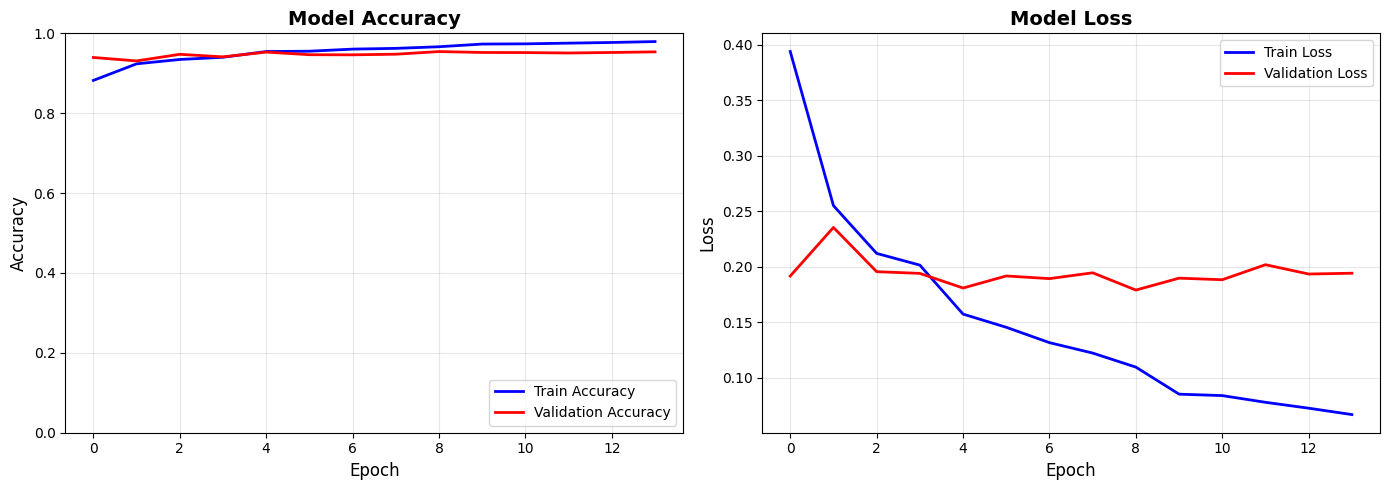

In [ ]:
# Plot akurasi dan loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot akurasi
ax1.plot(history.history['accuracy'], 'b-', label='Train Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1])

# Plot loss
ax2.plot(history.history['loss'], 'b-', label='Train Loss', linewidth=2)
ax2.plot(history.history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("📊 LAPORAN AKURASI MODEL")

# Evaluasi Train Set
train_loss, train_acc = model.evaluate(train_generator, verbose=0)
print(f"\n📌 TRAIN SET:")
print(f"   Loss: {train_loss:.4f}")
print(f"   Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")

# Evaluasi Validation Set
val_loss, val_acc = model.evaluate(validation_generator, verbose=0)
print(f"\n📌 VALIDATION SET:")
print(f"   Loss: {val_loss:.4f}")
print(f"   Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")

# Evaluasi Test Set
test_loss, test_acc = model.evaluate(test_generator, verbose=0)
print(f"\n📌 TEST SET:")
print(f"   Loss: {test_loss:.4f}")
print(f"   Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

📊 LAPORAN AKURASI MODEL

📌 TRAIN SET:
   Loss: 0.0607
   Accuracy: 0.9807 (98.07%)

📌 VALIDATION SET:
   Loss: 0.1789
   Accuracy: 0.9544 (95.44%)

📌 TEST SET:
   Loss: 0.1533
   Accuracy: 0.9553 (95.53%)


Berdasarkan laporan akurasi, model menunjukkan performa yang sangat baik. Pada data **training**, model mencapai akurasi **98.07%** dengan loss 0.0607, mengindikasikan model berhasil mempelajari pola data dengan sangat baik. Pada data **validation**, akurasi mencapai **95.44%** dengan loss 0.1789, sementara pada data **test** diperoleh akurasi **95.53%** dengan loss 0.1533. Selisih yang kecil antara akurasi training, validation, dan test (sekitar 2-3%) menunjukkan bahwa model tidak mengalami overfitting dan mampu generalisasi dengan baik terhadap data baru yang belum pernah dilihat sebelumnya.

In [ ]:
# Prediksi data test
print("Sedang memprediksi data test...")
y_pred_probs = model.predict(test_generator, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Nama kelas
class_names = list(test_generator.class_indices.keys())

# Tampilkan classification report
print("\nHasil Classification Report:")
print("-" * 50)
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

Sedang memprediksi data test...

Hasil Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

        cane       0.97      0.95      0.96       730
     cavallo       0.93      0.96      0.94       394
    elefante       0.94      0.97      0.95       218
    farfalla       0.98      0.97      0.97       318
     gallina       0.98      0.98      0.98       466
       gatto       0.91      0.97      0.94       251
       mucca       0.89      0.91      0.90       281
      pecora       0.91      0.89      0.90       273
       ragno       0.98      0.98      0.98       724
  scoiattolo       0.97      0.94      0.95       280

    accuracy                           0.96      3935
   macro avg       0.95      0.95      0.95      3935
weighted avg       0.96      0.96      0.96      3935



Model mencapai **akurasi** keseluruhan **96%** pada data **test**. Hampir semua kelas memiliki **f1-score di atas 90%**, dengan kelas terbaik adalah farfalla, gallina, dan ragno (97-98%). Kelas dengan performa terendah adalah mucca (90%) diikuti pecora (90%) dan gatto (94%).

## Konversi Model

Setelah training selesai, model **disimpan** dalam tiga format untuk keperluan deployment yang berbeda. **SavedModel** disimpan sebagai format standar TensorFlow untuk deployment server. **TF-Lite** dikonversi untuk digunakan pada aplikasi mobile/HP. **TFJS** (TensorFlow.js) disimpan untuk dijalankan langsung di website atau browser.

In [ ]:
# Buat folder untuk menyimpan model
os.makedirs('saved_models', exist_ok=True)

# SavedModel
print("\n📍 Langkah 1: Menyimpan SavedModel...")
model.export('saved_models/saved_model')
print("   ✅ SavedModel berhasil disimpan ya~")


# TF-Lite (buat mobile)
print("\n📍 Langkah 2: Menyimpan TF-Lite...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('saved_models/model.tflite', 'wb') as f:
    f.write(tflite_model)
print("   ✅ TF-Lite berhasil disimpan")

# TFJS (buat website)
print("\n📍 Langkah 3: Menyimpan TFJS...")
!pip install tensorflowjs -q
import tensorflowjs as tfjs
tfjs.converters.save_keras_model(model, 'saved_models/tfjs_model')
print("   ✅ TFJS berhasil disimpan")

print("🎉 SELESAI! Modelnya sudah aman tersimpan")
print("\n📁 Semua model ada di folder: saved_models/")
print("   📦 SavedModel - buat deployment server")
print("   📱 TF-Lite    - buat aplikasi mobile/HP")
print("   🌐 TFJS       - buat website/browser")


📍 Langkah 1: Menyimpan SavedModel...
INFO:tensorflow:Assets written to: saved_models/saved_model/assets


INFO:tensorflow:Assets written to: saved_models/saved_model/assets


Saved artifact at 'saved_models/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_321')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  132757972963344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132757972968720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132757972968528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132757972966800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132757972969104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132757972966416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132757972968336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132757972968912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132757972968144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132757972970064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1

INFO:tensorflow:Assets written to: /tmp/tmp7slj9qo7/assets


Saved artifact at '/tmp/tmp7slj9qo7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_321')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  132757972963344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132757972968720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132757972968528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132757972966800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132757972969104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132757972966416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132757972968336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132757972968912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132757972968144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132757972970064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132757972

W0000 00:00:1777257836.138228      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777257836.138288      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777257836.288641      55 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


   ✅ TF-Lite berhasil disimpan

📍 Langkah 3: Menyimpan TFJS...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 2.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ray 2.54.0 requires packaging>=24.2, but you have packaging 23.2 which is incompatible.
build 1.4.0 requires packaging>=24.0, but you have packaging 23.2 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but 

failed to lookup keras version from the file,
    this is likely a weight only file
   ✅ TFJS berhasil disimpan
🎉 SELESAI! Modelnya sudah aman tersimpan

📁 Semua model ada di folder: saved_models/
   📦 SavedModel - buat deployment server
   📱 TF-Lite    - buat aplikasi mobile/HP
   🌐 TFJS       - buat website/browser


Selanjutnya, daftar kelas yang benar (dalam bahasa Italia: cane, cavallo, elefante, farfalla, gallina, gatto, mucca, pecora, ragno, scoiattolo) disimpan ke dalam file labels.txt.

In [ ]:
class_names_correct = ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina',
                       'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']

print("📋 Daftar kelas yang benar:")
for i, nama in enumerate(class_names_correct):
    print(f"   {i}: {nama}")

labels_path = 'saved_models/labels.txt'
with open(labels_path, 'w') as f:
    for label in class_names_correct:
        f.write(label + '\n')

print(f"\n✅ labels.txt sudah diperbaiki!")
print(f"📁 Lokasi: {labels_path}")

print("\n📄 Isi labels.txt:")
print("-" * 30)
with open(labels_path, 'r') as f:
    for i, line in enumerate(f):
        print(f"{i}: {line.strip()}")

📋 Daftar kelas yang benar:
   0: cane
   1: cavallo
   2: elefante
   3: farfalla
   4: gallina
   5: gatto
   6: mucca
   7: pecora
   8: ragno
   9: scoiattolo

✅ labels.txt sudah diperbaiki!
📁 Lokasi: saved_models/labels.txt

📄 Isi labels.txt:
------------------------------
0: cane
1: cavallo
2: elefante
3: farfalla
4: gallina
5: gatto
6: mucca
7: pecora
8: ragno
9: scoiattolo


## Inference

Model diuji pada folder berisi gambar-gambar hewan baru **menggunakan TensorFlow Lite (TFLite)**.

INFERENCE DENGAN TF-LITE

📂 Load model: /content/saved_model/model.tflite
✅ Model siap!
   Input shape: [  1 224 224   3]
   Output shape: [ 1 10]
✅ Labels: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']

📂 Ditemukan 3 gambar

🖼️ WhatsApp Image 2026-04-27 at 09.59.14.jpeg -> ragno (100.00%)
🖼️ WhatsApp Image 2026-04-27 at 09.59.15 (1).jpeg -> gatto (100.00%)
🖼️ WhatsApp Image 2026-04-27 at 09.59.15.jpeg -> pecora (100.00%)


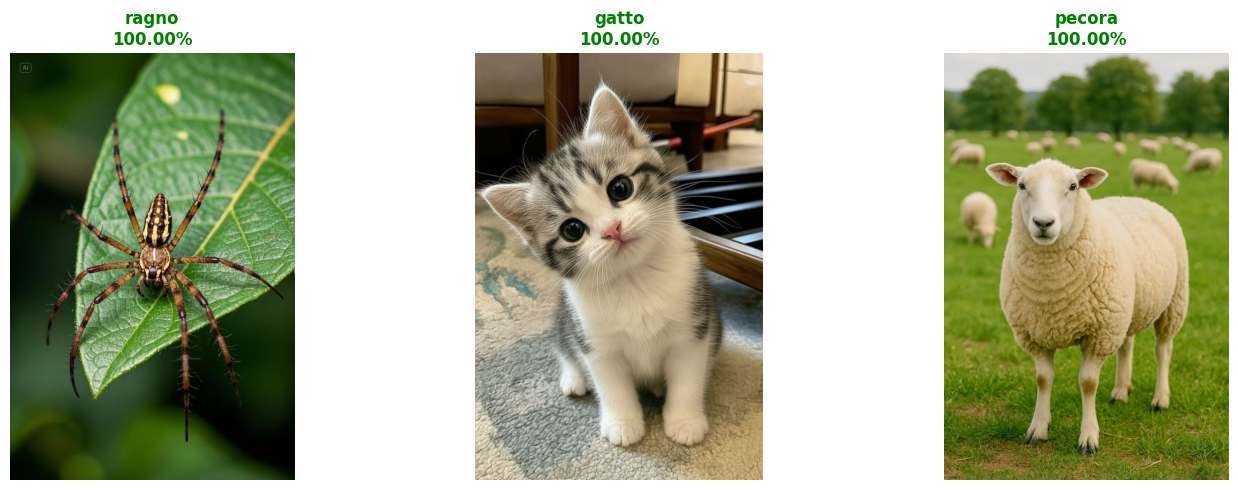


📊 RINGKASAN HASIL
1. WhatsApp Image 2026-04-27 at 09.59.14.jpeg -> ragno (100.00%)
2. WhatsApp Image 2026-04-27 at 09.59.15 (1).jpeg -> gatto (100.00%)
3. WhatsApp Image 2026-04-27 at 09.59.15.jpeg -> pecora (100.00%)

✅ INFERENCE SELESAI!


In [5]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import os

print("INFERENCE DENGAN TF-LITE")

# Load model TF-Lite
tflite_path = '/content/saved_model/model.tflite'

# Cari otomatis
for root, dirs, files in os.walk('/content'):
    for file in files:
        if file.endswith('.tflite'):
            tflite_path = os.path.join(root, file)
            break

print(f"\n📂 Load model: {tflite_path}")
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

# Dapatkan input dan output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f"✅ Model siap!")
print(f"   Input shape: {input_details[0]['shape']}")
print(f"   Output shape: {output_details[0]['shape']}")

# Load labels
labels_path = '/content/labels.txt'
if os.path.exists(labels_path):
    with open(labels_path, 'r') as f:
        labels = [line.strip() for line in f.readlines()]
    print(f"✅ Labels: {labels}")
else:
    labels = [f"Kelas_{i}" for i in range(10)]
    print(f"⚠️ Labels tidak ditemukan, pakai indeks")

# Fungsi prediksi
def predict_tflite(img_path):
    # Load dan preprocess gambar
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array.astype(np.float32) / 255.0

    # Set input
    interpreter.set_tensor(input_details[0]['index'], img_array)

    # Jalankan prediksi
    interpreter.invoke()

    # Ambil output
    output = interpreter.get_tensor(output_details[0]['index'])
    idx = np.argmax(output[0])
    confidence = output[0][idx]

    return labels[idx], confidence

# Prediksi semua gambar
folder_gambar = '/content/Gambar'
gambar_files = [f for f in os.listdir(folder_gambar)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"\n📂 Ditemukan {len(gambar_files)} gambar\n")

results = []
for img_file in gambar_files:
    img_path = os.path.join(folder_gambar, img_file)
    label, conf = predict_tflite(img_path)
    results.append((img_file, label, conf))
    print(f"🖼️ {img_file} -> {label} ({conf:.2%})")

# Tampilkan gambar
if results:
    fig, axes = plt.subplots(1, len(results), figsize=(15, 5))
    if len(results) == 1:
        axes = [axes]

    for i, (img_file, label, conf) in enumerate(results):
        img = plt.imread(os.path.join(folder_gambar, img_file))
        axes[i].imshow(img)
        axes[i].set_title(f"{label}\n{conf:.2%}", fontweight='bold', color='green')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    # 6. Ringkasan
    print("\n" + "="*50)
    print("📊 RINGKASAN HASIL")
    print("="*50)
    for i, (img_file, label, conf) in enumerate(results, 1):
        print(f"{i}. {img_file} -> {label} ({conf:.2%})")

print("\n✅ INFERENCE SELESAI!")

Hasil prediksi pada 3 gambar menunjukkan performa model yang sempurna dengan tingkat confidence 100% untuk semua gambar. Model berhasil mengidentifikasi gambar sebagai ragno (laba-laba), gatto (kucing), dan pecora (domba) dengan keyakinan penuh. Rata-rata confidence mencapai 100%, menegaskan bahwa model sangat yakin dengan setiap prediksi yang dibuat.